In [8]:
import pandas as pd

# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/car/car.data"
cols = ["buying", "maint", "doors", "persons", "lug_boot", "safety", "class"]
df = pd.read_csv(url, names=cols)

In [9]:
df.head()

,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   object
 1   maint     1728 non-null   object
 2   doors     1728 non-null   object
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: object(7)
memory usage: 94.6+ KB


In [11]:
df['class'].value_counts()

,count
class,
unacc,1210
acc,384
good,69
vgood,65


<Axes: xlabel='buying'>

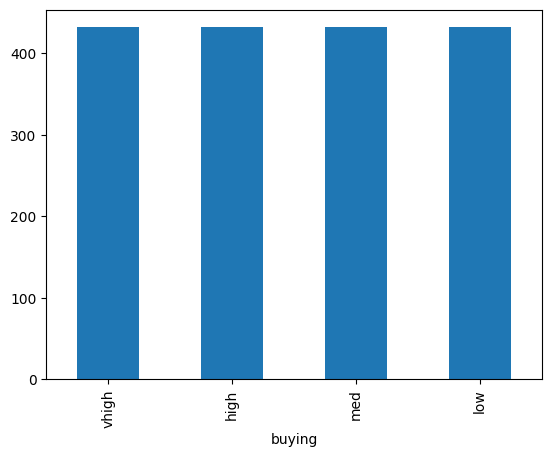

In [15]:
df['buying'].value_counts().plot(kind = 'bar')

In [17]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['buying'] = le.fit_transform(df['buying'])

In [18]:
df['buying'].value_counts()

,count
buying,
3,432
0,432
2,432
1,432


In [19]:
df['maint'].value_counts()

,count
maint,
vhigh,432
high,432
med,432
low,432


In [20]:
df['doors'].value_counts()

,count
doors,
2,432
3,432
4,432
5more,432


In [21]:
df['doors'] = df['doors'].replace('5more', 5)
df['doors'] = df['doors'].astype(int)

In [22]:
df['doors'].value_counts()

,count
doors,
2,432
3,432
4,432
5,432


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   buying    1728 non-null   int64 
 1   maint     1728 non-null   object
 2   doors     1728 non-null   int64 
 3   persons   1728 non-null   object
 4   lug_boot  1728 non-null   object
 5   safety    1728 non-null   object
 6   class     1728 non-null   object
dtypes: int64(2), object(5)
memory usage: 94.6+ KB


In [24]:
df['persons'].value_counts()

,count
persons,
2,576
4,576
more,576


In [25]:
df['persons'] = df['persons'].replace('more', 5)
df['persons'] = df['persons'].astype(int)

In [26]:
df['persons'].value_counts()

,count
persons,
2,576
4,576
5,576


In [27]:
df['lug_boot'].value_counts()

,count
lug_boot,
small,576
med,576
big,576


In [28]:
df['safety'].value_counts()

,count
safety,
low,576
med,576
high,576


In [29]:
df['class'].value_counts()

,count
class,
unacc,1210
acc,384
good,69
vgood,65


In [30]:
cols = ['maint', 'lug_boot', 'safety', 'class']
for col in cols:
    df[col] = le.fit_transform(df[col])

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1728 entries, 0 to 1727
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   buying    1728 non-null   int64
 1   maint     1728 non-null   int64
 2   doors     1728 non-null   int64
 3   persons   1728 non-null   int64
 4   lug_boot  1728 non-null   int64
 5   safety    1728 non-null   int64
 6   class     1728 non-null   int64
dtypes: int64(7)
memory usage: 94.6 KB


In [32]:
df

,buying,maint,doors,persons,lug_boot,safety,class
0,3,3,2,2,2,1,2
1,3,3,2,2,2,2,2
2,3,3,2,2,2,0,2
3,3,3,2,2,1,1,2
4,3,3,2,2,1,2,2
...,...,...,...,...,...,...,...
1723,1,1,5,5,1,2,1
1724,1,1,5,5,1,0,3
1725,1,1,5,5,0,1,2
1726,1,1,5,5,0,2,1


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.metrics import classification_report, confusion_matrix

In [41]:
x = df.drop('class', axis = 1)
y = df['class']
x_train, x_test, y_train , y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

In [42]:
catnb = CategoricalNB()
catnb.fit(x_train, y_train)

CategoricalNB()

In [43]:
pred = catnb.predict(x_test)
print(classification_report(y_test,pred))
print(confusion_matrix(y_test,pred))

              precision    recall  f1-score   support

           0       0.68      0.69      0.68        77
           1       0.60      0.43      0.50        14
           2       0.92      0.96      0.94       242
           3       1.00      0.38      0.56        13

    accuracy                           0.86       346
   macro avg       0.80      0.62      0.67       346
weighted avg       0.86      0.86      0.85       346

[[ 53   4  20   0]
 [  8   6   0   0]
 [  9   0 233   0]
 [  8   0   0   5]]


In [46]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state = 42, sampling_strategy= 'auto')
x_res , y_res= smote.fit_resample(x_train, y_train)
catnb.fit(x_res, y_res)
pred2 = catnb.predict(x_test)
print(classification_report(y_test,pred2))
print(confusion_matrix(y_test,pred2))

              precision    recall  f1-score   support

           0       0.63      0.88      0.74        77
           1       0.67      1.00      0.80        14
           2       1.00      0.83      0.91       242
           3       0.80      0.92      0.86        13

    accuracy                           0.86       346
   macro avg       0.77      0.91      0.83       346
weighted avg       0.90      0.86      0.86       346

[[ 68   6   0   3]
 [  0  14   0   0]
 [ 40   0 202   0]
 [  0   1   0  12]]


  0%|          | 0/346 [00:00<?, ?it/s]

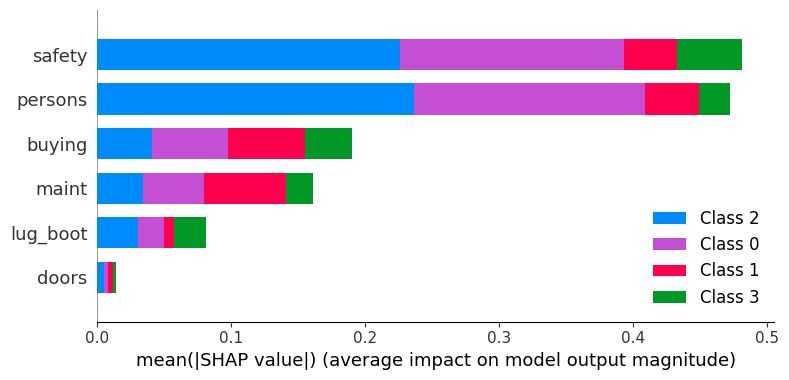

In [51]:
import shap
import matplotlib.pyplot as plt

# Use KernelExplainer which is model-agnostic
explainer = shap.KernelExplainer(catnb.predict_proba, x_train)
shap_values = explainer.shap_values(x_test)

# Summarize the SHAP values
shap.summary_plot(shap_values, x_test.values, feature_names=x_test.columns, plot_type="bar")
plt.show()